In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

# Dataset paths
occupancy = pd.read_csv("dataset/lot_occupancy_hourly.csv")
parking = pd.read_csv("dataset/parking_lots.csv")
reviews = pd.read_csv("dataset/reviews.csv")

print("Occupancy:", occupancy.shape)
print("Parking lots:", parking.shape)
print("Reviews:", reviews.shape)


Occupancy: (4575, 11)
Parking lots: (40, 13)
Reviews: (1500, 8)


In [2]:
# Create average rating for each parking lot
rating_df = (
    reviews.groupby("lot_id", as_index=False)
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("rating", "count")
    )
)

# Merge occupancy + parking details + ratings
df = (
    occupancy
    .merge(
        parking[
            [
                "parking_lots_id", "name", "address", "latitude", "longitude",
                "price_per_hour", "total_slots", "vehicle_type", "status"
            ]
        ],
        left_on="lot_id",
        right_on="parking_lots_id",
        how="left"
    )
    .merge(rating_df, on="lot_id", how="left")
)

# Fill missing ratings with the overall review mean
df["avg_rating"] = df["avg_rating"].fillna(reviews["rating"].mean())
df["price"] = df["price_per_hour"]

print("Merged shape:", df.shape)
df.head()


Merged shape: (4575, 23)


,lot_id,date,hour,day_of_week,is_weekend,is_festival,weather_condition,avg_price,bookings_count,total_slots_x,occupancy_pct,parking_lots_id,name,address,latitude,longitude,price_per_hour,total_slots_y,vehicle_type,status,avg_rating,review_count,price
0,P101,2025-10-03,10,Friday,False,False,haze,20.32,26,66,39.4,P101,Rohini Parking A,"Rohini, Delhi",28.746245,77.058964,20.85,66,car,approved,3.863636,44,20.85
1,P101,2025-10-04,22,Saturday,True,False,cloudy,22.83,36,66,54.5,P101,Rohini Parking A,"Rohini, Delhi",28.746245,77.058964,20.85,66,car,approved,3.863636,44,20.85
2,P101,2025-10-05,1,Sunday,True,False,clear,23.60,3,66,4.5,P101,Rohini Parking A,"Rohini, Delhi",28.746245,77.058964,20.85,66,car,approved,3.863636,44,20.85
3,P101,2025-10-05,3,Sunday,True,False,clear,23.51,3,66,4.5,P101,Rohini Parking A,"Rohini, Delhi",28.746245,77.058964,20.85,66,car,approved,3.863636,44,20.85
4,P101,2025-10-06,9,Monday,False,False,cloudy,26.20,22,66,33.3,P101,Rohini Parking A,"Rohini, Delhi",28.746245,77.058964,20.85,66,car,approved,3.863636,44,20.85


In [3]:
# User location used for distance calculation.
# Replace these values with the actual user/destination coordinates.
USER_LAT = 25.6242129
USER_LON = 85.0850287

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(
    USER_LAT,
    USER_LON,
    df["latitude"].values,
    df["longitude"].values
)

df[[
    "name", "address", "price",
    "avg_rating", "distance_km", "occupancy_pct"
]].head()


,name,address,price,avg_rating,distance_km,occupancy_pct
0,Rohini Parking A,"Rohini, Delhi",20.85,3.863636,866.171592,39.4
1,Rohini Parking A,"Rohini, Delhi",20.85,3.863636,866.171592,54.5
2,Rohini Parking A,"Rohini, Delhi",20.85,3.863636,866.171592,4.5
3,Rohini Parking A,"Rohini, Delhi",20.85,3.863636,866.171592,4.5
4,Rohini Parking A,"Rohini, Delhi",20.85,3.863636,866.171592,33.3


In [4]:
## Train the Occupancy Prediction Model
'''
Target: `occupancy_pct`

**Features:**
- `price`
- `avg_rating`
- `distance_km`
'''


features = ["price", "avg_rating", "distance_km"]
target = "occupancy_pct"

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

# Same accuracy-style metric used in the original notebook
accuracy = 100 - (
    mae / np.mean(np.abs(y_test)) * 100
)

print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R²       : {r2:.3f}")
print(f"Accuracy : {accuracy:.2f}%")


MAE      : 16.74
RMSE     : 20.29
R²       : 0.216
Accuracy : 58.80%


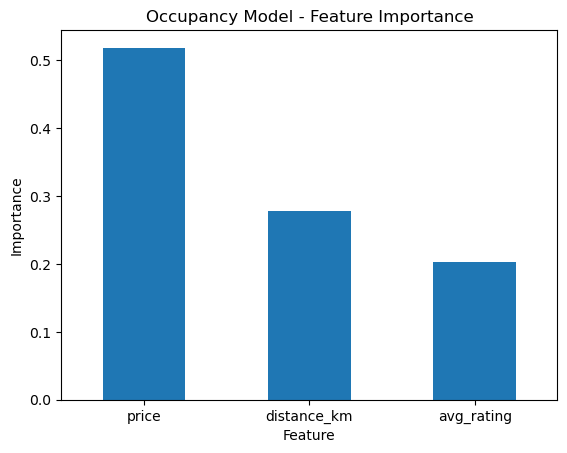

In [5]:
# Feature importance
importance = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

importance.plot(kind="bar")
plt.title("Occupancy Model - Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=0)
plt.show()


In [6]:
# Save the trained occupancy model and the information needed by
# the recommendation notebook.
model_bundle = {
    "model": model,
    "features": features,
    "user_lat": USER_LAT,
    "user_lon": USER_LON
}

joblib.dump(model_bundle, "occupancy_model.joblib")

print("Saved: occupancy_model.joblib")


Saved: occupancy_model.joblib


In [7]:
# Load the saved occupancy model
bundle = joblib.load("occupancy_model.joblib")

loaded_model = bundle["model"]
features = bundle["features"]

# Generate occupancy predictions
df["predicted_occupancy"] = loaded_model.predict(df[features])

# Keep predictions between 0 and 100
df["predicted_occupancy"] = df["predicted_occupancy"].clip(0, 100)

# Display predictions
print(df[features + ["predicted_occupancy"]].head(10))

   price  avg_rating  distance_km  predicted_occupancy
0  20.85    3.863636   866.171592            47.794234
1  20.85    3.863636   866.171592            47.794234
2  20.85    3.863636   866.171592            47.794234
3  20.85    3.863636   866.171592            47.794234
4  20.85    3.863636   866.171592            47.794234
5  20.85    3.863636   866.171592            47.794234
6  20.85    3.863636   866.171592            47.794234
7  20.85    3.863636   866.171592            47.794234
8  20.85    3.863636   866.171592            47.794234
9  20.85    3.863636   866.171592            47.794234


In [8]:
print(df.columns.tolist())

['lot_id', 'date', 'hour', 'day_of_week', 'is_weekend', 'is_festival', 'weather_condition', 'avg_price', 'bookings_count', 'total_slots_x', 'occupancy_pct', 'parking_lots_id', 'name', 'address', 'latitude', 'longitude', 'price_per_hour', 'total_slots_y', 'vehicle_type', 'status', 'avg_rating', 'review_count', 'price', 'distance_km', 'predicted_occupancy']


In [9]:
# Create data for the ML-based heatmap

heatmap_df = df[
    [
        "lot_id",
        "name",
        "latitude",
        "longitude",
        "predicted_occupancy"
    ]
].dropna()

# Keep predictions within 0–100%
heatmap_df["predicted_occupancy"] = heatmap_df[
    "predicted_occupancy"
].clip(0, 100)

print(heatmap_df.head(10))

  lot_id              name   latitude  longitude  predicted_occupancy
0   P101  Rohini Parking A  28.746245  77.058964            47.794234
1   P101  Rohini Parking A  28.746245  77.058964            47.794234
2   P101  Rohini Parking A  28.746245  77.058964            47.794234
3   P101  Rohini Parking A  28.746245  77.058964            47.794234
4   P101  Rohini Parking A  28.746245  77.058964            47.794234
5   P101  Rohini Parking A  28.746245  77.058964            47.794234
6   P101  Rohini Parking A  28.746245  77.058964            47.794234
7   P101  Rohini Parking A  28.746245  77.058964            47.794234
8   P101  Rohini Parking A  28.746245  77.058964            47.794234
9   P101  Rohini Parking A  28.746245  77.058964            47.794234


In [10]:
print("Total rows:", len(df))
print("Unique parking lots:", df["lot_id"].nunique())


Total rows: 4575
Unique parking lots: 32


In [11]:
print(
    df.groupby("lot_id").size().sort_values(ascending=False).head(10)
)

lot_id
P125    163
P110    161
P121    157
P107    157
P128    156
P120    154
P109    153
P103    153
P119    153
P132    153
dtype: int64


In [12]:
# Create one heatmap point per parking lot

heatmap_df = (
    df.groupby("lot_id")
      .agg({
          "name": "first",
          "latitude": "first",
          "longitude": "first",
          "predicted_occupancy": "mean"
      })
      .reset_index()
)

# Keep predictions within 0–100%
heatmap_df["predicted_occupancy"] = (
    heatmap_df["predicted_occupancy"].clip(0, 100)
)

print("Number of parking lots:", len(heatmap_df))
print(heatmap_df.head(10))

Number of parking lots: 32
  lot_id                       name   latitude  longitude  predicted_occupancy
0   P101           Rohini Parking A  28.746245  77.058964            47.794234
1   P102            Saket Parking B  28.521139  77.203302            44.558446
2   P103     Lajpat Nagar Parking C  28.569873  77.240638            36.458598
3   P104      Nehru Place Parking D  28.549175  77.254786            28.096200
4   P105        Pitampura Parking E  28.699170  77.133056            43.328331
5   P106        Janakpuri Parking A  28.620621  77.085919            49.277021
6   P107  Greater Kailash Parking B  28.553980  77.240237            52.826777
7   P108     Lajpat Nagar Parking C  28.566360  77.243951            31.909584
8   P109        Pitampura Parking D  28.702073  77.130505            33.450968
9   P110        Pitampura Parking E  28.698135  77.126797            61.483735


In [13]:
import json

heatmap_data = heatmap_df.to_dict(orient="records")

with open("heatmap_predictions.json", "w") as f:
    json.dump(heatmap_data, f, indent=4)

print("Saved: heatmap_predictions.json")

Saved: heatmap_predictions.json


In [14]:
import json

with open("heatmap_predictions.json", "r") as f:
    data = json.load(f)

print("Total heatmap locations:", len(data))
print(data[:3])

Total heatmap locations: 32
[{'lot_id': 'P101', 'name': 'Rohini Parking A', 'latitude': 28.746245, 'longitude': 77.058964, 'predicted_occupancy': 47.79423444275521}, {'lot_id': 'P102', 'name': 'Saket Parking B', 'latitude': 28.521139, 'longitude': 77.203302, 'predicted_occupancy': 44.55844566838842}, {'lot_id': 'P103', 'name': 'Lajpat Nagar Parking C', 'latitude': 28.569873, 'longitude': 77.240638, 'predicted_occupancy': 36.458598115911116}]


In [15]:
# 1. Select features
features = [
    "price",
    "avg_rating",
    "distance_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_festival",
    "weather_condition"
]
target = "occupancy_pct"


In [16]:
model_df = df[features + [target]].copy()
model_df = model_df.dropna()
print("Rows used:", len(model_df))

Rows used: 4575


In [17]:
X = model_df[features]
y = model_df[target]
categorical_features = [
    "weather_condition"
]

categorical_features = [
    "day_of_week",
    "weather_condition"
]

numeric_features = [
    "price",
    "avg_rating",
    "distance_km",
    "hour",
    "is_weekend",
    "is_festival"
]


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)


In [19]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [21]:
pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [22]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("R2 Score:", round(r2, 3))

MAE: 4.877
R2 Score: 0.912


In [23]:
joblib.dump(
    pipeline,
    "occupancy_model.joblib"
)

print("Saved: occupancy_model.joblib")

Saved: occupancy_model.joblib


In [24]:
print("Target statistics:")
print(df["occupancy_pct"].describe())

print("\nCorrelation with occupancy:")
print(
    df[
        [
            "price",
            "avg_rating",
            "distance_km",
            "hour",
            "is_weekend",
            "is_festival",
            "bookings_count",
            "occupancy_pct"
        ]
    ].corr(numeric_only=True)["occupancy_pct"].sort_values(ascending=False)
)

Target statistics:
count    4575.000000
mean       40.655497
std        23.526028
min         0.000000
25%        23.400000
50%        37.100000
75%        56.000000
max       100.000000
Name: occupancy_pct, dtype: float64

Correlation with occupancy:
occupancy_pct     1.000000
bookings_count    0.758465
hour              0.647110
is_weekend        0.187065
is_festival       0.148073
distance_km       0.060640
avg_rating       -0.056555
price            -0.074952
Name: occupancy_pct, dtype: float64


In [25]:
print(df[[
    "hour",
    "day_of_week",
    "weather_condition",
    "bookings_count",
    "occupancy_pct"
]].head(20))

    hour day_of_week weather_condition  bookings_count  occupancy_pct
0     10      Friday              haze              26           39.4
1     22    Saturday            cloudy              36           54.5
2      1      Sunday             clear               3            4.5
3      3      Sunday             clear               3            4.5
4      9      Monday            cloudy              22           33.3
5     19      Monday             clear              40           60.6
6      8     Tuesday            cloudy              17           25.8
7     17     Tuesday             clear              54           81.8
8     18   Wednesday             clear              57           86.4
9     15    Thursday             clear              44           66.7
10    18    Thursday              haze              43           65.2
11    14    Saturday             clear              44           66.7
12    22    Saturday            cloudy              37           56.1
13     6     Tuesday

In [26]:
print(df[[
    "bookings_count",
    "total_slots_x",
    "occupancy_pct"
]].head(20))

    bookings_count  total_slots_x  occupancy_pct
0               26             66           39.4
1               36             66           54.5
2                3             66            4.5
3                3             66            4.5
4               22             66           33.3
5               40             66           60.6
6               17             66           25.8
7               54             66           81.8
8               57             66           86.4
9               44             66           66.7
10              43             66           65.2
11              44             66           66.7
12              37             66           56.1
13              15             66           22.7
14               5             66            7.6
15               2             66            3.0
16              28             66           42.4
17              51             66           77.3
18              65             66           98.5
19              47  

In [27]:
print(
    df.groupby("hour")["occupancy_pct"]
      .agg(["count", "min", "max", "mean"])
)

      count   min    max       mean
hour                               
0        51   0.0    5.9   2.705882
1        43   1.4    5.9   2.897674
2        49   1.5    5.9   3.124490
3        50   1.5    5.9   2.950000
4        55   1.5    6.4   3.420000
5        79   3.6   29.4  15.794937
6       167   5.2   36.2  18.538323
7       327   6.5   47.1  21.721713
8       404   9.7   55.3  25.400000
9       272   8.9   70.6  29.292647
10      186  10.7   70.6  31.233871
11      181  12.5   82.4  34.079558
12      224  12.5   98.5  38.862946
13      213  16.1  100.0  41.306103
14      185   8.9  100.0  46.401081
15      181  10.7  100.0  50.655801
16      233  14.3  100.0  54.578112
17      348  10.7  100.0  62.400000
18      373  10.7  100.0  63.894370
19      368   8.9  100.0  61.538043
20      270   8.9  100.0  58.087407
21      171  21.3   95.7  47.360234
22       80   5.4   88.2  39.460000
23       65   1.8   12.8   7.506154
